# Module Lab: Unsupervised Learning in a Mining Environment

## Scenario

You are working with a **mining operations analytics team** that receives equipment and site sensor readings every day.

Unlike supervised learning tasks, this time there is **no labelled target column** telling you which records belong to which group.  
Your job is to explore the data and look for **natural patterns, clusters, and unusual behaviour** that may help the operations team answer questions such as:

- Are there groups of machines behaving in similar ways?
- Do some operating patterns appear different from the rest?
- Can we separate readings into meaningful clusters for investigation or reporting?
- Are there signs of unusual conditions that might justify follow-up checks?

This is a common mining analytics problem because much of the available operational data is collected continuously, but is **not always labelled**.

## Key ideas

This lab introduces several important machine learning concepts:

- **unsupervised learning** looks for structure in data without a target label
- a **feature** is a measured input column such as vibration, temperature, or pressure
- **clustering** groups similar records together
- **scaling** is often important because features may use different numeric ranges
- **centroids** represent the centre of clusters in methods such as K-Means
- **inertia** helps measure how tightly grouped clusters are
- the **elbow method** can help estimate a useful number of clusters
- cluster interpretation matters just as much as running the code

## Learning goals

By the end of this lab, you should be able to:

1. load and inspect a mining dataset
2. identify useful numeric features for clustering
3. scale the data before applying unsupervised learning
4. build a K-Means clustering model
5. use the elbow method to help choose a cluster count
6. assign cluster labels to records
7. interpret cluster patterns in an operational mining context
8. recognise how clustering can support investigation, reporting, and anomaly review


## How to use this notebook

Work through the notebook from top to bottom.

### Running code cells

- Click inside a code cell.
- Press **Shift + Enter** to run it.
- Wait for the output before moving on.

### Recommended workflow

1. Read the explanation above the code cell.
2. Run the code.
3. Review the output and compare it with the explanation.
4. Answer the short reflection prompts in your own words.
5. Keep notes on what each cluster might represent operationally.

### If something goes wrong

- Re-run the current cell.
- Make sure the earlier setup cells were already run.
- Check that the dataset loaded correctly.
- If needed, restart the notebook kernel/runtime and run everything again from the top.

### How to read the code comments

The code comments are written to explain:

- what the code is doing
- how it is doing it
- what result it is trying to achieve
- why that method is suitable for this type of mining problem


## 1) Setup: import the required libraries


In [1]:
# Import the main Python tools used in this lab.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import preprocessing and clustering tools from scikit-learn.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set a fixed random state so the clustering result is repeatable.
# This helps keep workshop results more consistent between runs.
RANDOM_STATE = 42

# Import the libraries used in this workshop.
# Each library gives us a set of tools for a different kind of task.

import pandas as pd               # Work with tabular data such as CSV files
import numpy as np                # Perform numerical calculations with arrays
import matplotlib.pyplot as plt   # Create charts and visualisations

# Import distance and similarity functions from scikit-learn.
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

print("Environment ready ✅")



Environment ready ✅


### Why this section matters

Before exploring the data, we load the tools needed for:

- reading and inspecting tabular data
- scaling numeric features
- creating charts
- building a clustering model



## 2) Generate a simulated mining dataset

Instead of loading a dataset from a file, this notebook **generates synthetic mining operational data programmatically**.

This approach is useful for training workshops because:

- participants do not need to download any files
- the notebook runs immediately in environments such as Google Colab
- the generated data represents realistic mining operating conditions

The dataset simulates three equipment operating regimes:

1. **Normal operation** – stable operating conditions
2. **High-stress operation** – heavier loads and increased vibration
3. **Abnormal / risky operation** – potential fault conditions

Each observation includes measurements such as:

- engine temperature
- hydraulic pressure
- vibration
- load weight
- fuel rate
- vehicle speed


In [2]:

# Generate three operating regimes (simulated)

# Normal operation
normal = pd.DataFrame({
    "engine_temp": np.random.normal(75, 5, 300),
    "hydraulic_pressure": np.random.normal(210, 10, 300),
    "vibration": np.random.normal(2.0, 0.3, 300),
    "load_weight": np.random.normal(180, 15, 300),
    "fuel_rate": np.random.normal(95, 8, 300),
    "speed": np.random.normal(38, 4, 300),
})

# High-stress operation
high_stress = pd.DataFrame({
    "engine_temp": np.random.normal(90, 6, 200),
    "hydraulic_pressure": np.random.normal(250, 15, 200),
    "vibration": np.random.normal(3.5, 0.4, 200),
    "load_weight": np.random.normal(210, 20, 200),
    "fuel_rate": np.random.normal(120, 10, 200),
    "speed": np.random.normal(32, 4, 200),
})

# Abnormal / risky operation
abnormal = pd.DataFrame({
    "engine_temp": np.random.normal(105, 7, 100),
    "hydraulic_pressure": np.random.normal(280, 20, 100),
    "vibration": np.random.normal(5.0, 0.6, 100),
    "load_weight": np.random.normal(230, 25, 100),
    "fuel_rate": np.random.normal(145, 12, 100),
    "speed": np.random.normal(25, 5, 100),
})

# Combine the three regimes into a single dataset
df = pd.concat([normal, high_stress, abnormal], ignore_index=True)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (600, 6)


,engine_temp,hydraulic_pressure,vibration,load_weight,fuel_rate,speed
0,74.857695,204.924485,1.654747,153.852939,104.153057,37.449105
1,79.323224,192.676210,1.908009,168.531994,69.210669,47.138446
2,70.459142,220.119111,2.628321,175.369406,80.573768,39.869391
3,67.366801,207.434834,2.024283,164.716616,94.576519,34.597485
4,72.951273,218.151789,1.583193,179.624190,90.007105,46.133419


### Why we inspect the dataset first

Before applying clustering, we need to understand:

- what fields are available
- which columns are numeric
- whether the data appears complete enough to use
- whether some columns are identifiers rather than useful model inputs


## 3) Inspect the data structure


In [3]:
# Show the data types for each column.
# This helps us separate numeric features from identifiers or text fields.
df.dtypes


,0
engine_temp,float64
hydraulic_pressure,float64
vibration,float64
load_weight,float64
fuel_rate,float64
speed,float64


In [4]:
# View summary statistics for the numeric columns.
# This helps us understand the range, average, and spread of each feature.
df.describe()


,engine_temp,hydraulic_pressure,vibration,load_weight,fuel_rate,speed
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,84.938620,234.415961,2.994033,198.768240,111.852579,33.599531
std,12.066683,29.530293,1.159334,27.648751,20.993387,6.284542
min,62.568005,184.032050,1.348916,123.826393,68.966021,16.791380
25%,75.292550,211.092731,1.994799,177.758450,96.066554,29.373144
50%,82.778503,227.554601,2.722834,194.750547,106.070485,34.077766
75%,92.902496,253.058413,3.688653,216.499977,125.996788,38.043235
max,124.346099,323.101257,6.248378,289.369615,175.745550,47.339135


In [5]:
# Count missing values by column.
# Missing values matter because many ML algorithms cannot use them directly.
df.isna().sum()


,0
engine_temp,0
hydraulic_pressure,0
vibration,0
load_weight,0
fuel_rate,0
speed,0


### Reflection prompt

Look at the numeric columns and think about these questions:

1. Which columns look like genuine sensor or operational measurements?
2. Which columns might be IDs, labels, or descriptive text that should not be clustered directly?
3. Do any features appear to have much larger numeric ranges than others?

These questions matter because they affect which columns should be used and why scaling is important.


## 4) Select the clustering features

For clustering, we usually use **numeric operational features** only.

The next cell automatically selects numeric columns, then removes likely identifier columns if their names suggest they are IDs.


In [6]:
# Start with all numeric columns.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude columns that appear to be identifiers rather than measurements.
# This is a simple rule based on common naming patterns.
exclude_keywords = ["id", "index", "target", "label"]
feature_cols = [
    c for c in numeric_cols
    if not any(keyword in c.lower() for keyword in exclude_keywords)
]

print("Numeric columns found:")
print(numeric_cols)

print("\nFeature columns selected for clustering:")
print(feature_cols)


Numeric columns found:
['engine_temp', 'hydraulic_pressure', 'vibration', 'load_weight', 'fuel_rate', 'speed']

Feature columns selected for clustering:
['engine_temp', 'hydraulic_pressure', 'vibration', 'load_weight', 'fuel_rate', 'speed']


In [7]:
# Create the feature matrix X from the selected columns.
# This is the numeric data that K-Means will use.
X = df[feature_cols].copy()

# If there are missing values, fill them using the median of each column.
# Median is often a practical choice because it is less affected by extreme values.
X = X.fillna(X.median(numeric_only=True))

display(X.head())


,engine_temp,hydraulic_pressure,vibration,load_weight,fuel_rate,speed
0,74.857695,204.924485,1.654747,153.852939,104.153057,37.449105
1,79.323224,192.676210,1.908009,168.531994,69.210669,47.138446
2,70.459142,220.119111,2.628321,175.369406,80.573768,39.869391
3,67.366801,207.434834,2.024283,164.716616,94.576519,34.597485
4,72.951273,218.151789,1.583193,179.624190,90.007105,46.133419


### Why we remove IDs and fill missing values

- **IDs** are unique labels, not operational measurements. Including them can distort clustering.
- **Missing values** need to be handled because K-Means does not accept them directly.
- **Median filling** is a simple, practical way to make the dataset usable for workshop analysis.


## 5) Scale the features

Clustering is distance-based, so features on larger numeric ranges can dominate the result.

For example:

- temperature might be measured in tens
- pressure might be measured in hundreds
- vibration might be measured in small decimal values

If we do not scale the features, the largest-scale variable may influence the clusters too strongly.


In [8]:
# StandardScaler transforms each feature so it has:
# - mean close to 0
# - standard deviation close to 1
#
# This helps give each feature a more balanced influence in clustering.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)
print("\nFirst 5 scaled rows:")
print(np.round(X_scaled[:5], 3))


Scaled feature matrix shape: (600, 6)

First 5 scaled rows:
[[-0.836 -1.    -1.156 -1.626 -0.367  0.613]
 [-0.466 -1.415 -0.938 -1.094 -2.033  2.156]
 [-1.201 -0.485 -0.316 -0.847 -1.491  0.998]
 [-1.457 -0.914 -0.837 -1.233 -0.824  0.159]
 [-0.994 -0.551 -1.218 -0.693 -1.041  1.996]]


## 6) Explore a possible number of clusters with the elbow method

K-Means requires us to choose the number of clusters, called **k**.

One common approach is the **elbow method**, which compares how the model's inertia changes as k increases.

### What inertia means

Inertia measures how tightly the points are grouped around their assigned cluster centres.

- lower inertia usually means tighter clusters
- inertia always decreases as k increases
- the goal is to find a point where improvement starts slowing down


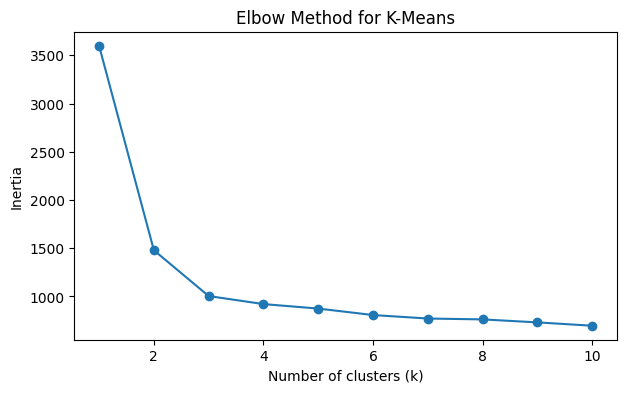

In [9]:
# Try several values of k and store the inertia for each one.
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    model.fit(X_scaled)
    inertias.append(model.inertia_)

# Plot the elbow chart.
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


### Reflection prompt

After viewing the elbow chart:

1. At what value of k does the curve begin to level off?
2. Is there a single obvious elbow, or are several values plausible?
3. If you were presenting to a mining operations team, how would you justify your chosen k?


## 7) Build a K-Means model

In the next cell, choose a cluster count and fit the model.

You can change `k` later if you want to compare different solutions.


In [11]:
# Choose the number of clusters.
# Adjust this value after reviewing the elbow chart.
k = 3

# Create and fit the K-Means clustering model.
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to the original DataFrame.
df["cluster"] = cluster_labels

# Display the first few rows with the new cluster label.
display(df.head(n=100))

display(df[df['cluster'] != 2])


,engine_temp,hydraulic_pressure,vibration,load_weight,fuel_rate,speed,cluster
0,74.857695,204.924485,1.654747,153.852939,104.153057,37.449105,2
1,79.323224,192.676210,1.908009,168.531994,69.210669,47.138446,2
2,70.459142,220.119111,2.628321,175.369406,80.573768,39.869391,2
3,67.366801,207.434834,2.024283,164.716616,94.576519,34.597485,2
4,72.951273,218.151789,1.583193,179.624190,90.007105,46.133419,2
...,...,...,...,...,...,...,...
95,74.640764,213.272040,2.635553,172.530881,99.790080,37.829390,2
96,78.429888,223.904156,1.608174,173.791127,105.236859,37.162484,2
97,74.352570,184.032050,2.058490,191.122487,97.036673,40.140438,2
98,73.394340,232.802932,1.723048,172.606515,99.905701,43.087141,2


### What this step achieves

K-Means assigns every row to one cluster.

That means each observation is grouped with other observations that appear similar according to the selected features and the distance calculations used by the algorithm.


## 8) Review cluster sizes


In [ ]:
# Count how many rows were assigned to each cluster.
# This helps us see whether the clusters are balanced or uneven.
cluster_counts = df["cluster"].value_counts().sort_index()
print(cluster_counts)


### Why cluster size matters

Cluster sizes can help with interpretation:

- very small clusters may represent unusual behaviour
- very large clusters may represent common operating patterns
- uneven cluster sizes are not automatically a problem, but they are worth noticing


## 9) Compare cluster profiles


In [ ]:
# Calculate the average feature values inside each cluster.
# This helps us understand how clusters differ from one another.
cluster_profile = df.groupby("cluster")[feature_cols].mean().round(2)
display(cluster_profile)


In [ ]:
# Plot the cluster profiles so differences are easier to compare visually.
cluster_profile.T.plot(kind="bar", figsize=(10, 5))
plt.title("Average Feature Values by Cluster")
plt.ylabel("Average value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### How to interpret cluster profiles

Use the average feature values to describe each cluster.

For example, you might identify a cluster as:

- higher vibration and higher temperature
- lower pressure but stable humidity
- generally average across most features

The goal is not only to produce clusters, but to explain what they may represent operationally.


## 10) Visualise the clusters


In [ ]:
# Select the first two feature columns for a simple 2D visualisation.
# This is only a visual aid. The actual clustering used all selected features.
plot_x = feature_cols[0]
plot_y = feature_cols[1] if len(feature_cols) > 1 else feature_cols[0]

plt.figure(figsize=(7, 5))
plt.scatter(df[plot_x], df[plot_y], c=df["cluster"])
plt.xlabel(plot_x)
plt.ylabel(plot_y)
plt.title("Cluster visualisation using two features")
plt.show()


### Important note about this chart

This plot only shows two features, so it is a simplified view of a higher-dimensional clustering result.

That means:

- some cluster overlap in the chart is normal
- the full model may still separate points using other features not shown here


## 11) Investigate possible unusual observations

Small clusters or edge points can sometimes indicate unusual operating patterns.

The next cell helps you inspect a few records from each cluster.


In [ ]:
# Show a small sample of rows from each cluster.
# This can help you inspect whether some clusters appear unusual or operationally distinct.
for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c} sample rows:")
    display(df[df["cluster"] == c].head(3))


## 12) Guided practice task

Try the following before moving on:

1. change the value of `k` to another number such as 2, 4, or 5
2. re-run the model fitting and profiling cells
3. compare the cluster sizes and cluster profiles
4. decide which value of `k` gives the most useful operational grouping

### Questions to answer

- Which value of k gives the clearest cluster story?
- Which cluster looks most unusual?
- Which cluster might represent stable operating behaviour?


## 13) Optional extension: relate clustering to operational action

Imagine you need to present these clusters to mine operations or maintenance teams.

Write short labels or descriptions for each cluster, such as:

- **stable operating state**
- **high-vibration group**
- **possible review group**
- **mixed environmental conditions**

This turns the technical result into something operational teams can use more easily.


## 14) Reflection questions

Write your answers in a new Markdown cell.

1. Why is scaling important before K-Means clustering?
2. Why should identifier columns usually be excluded?
3. What does the elbow method help you decide?
4. Why can cluster interpretation be subjective?
5. How might clustering support mining operations in practice?


## Wrap-up

You have completed an unsupervised learning lab using mining-style operational data.

### What you covered

- loading and inspecting a dataset
- selecting numeric features for clustering
- handling missing values
- scaling features
- using the elbow method
- fitting a K-Means model
- assigning cluster labels
- interpreting cluster profiles in a mining context

### Practical mining applications

Clustering can support activities such as:

- grouping similar equipment behaviour
- identifying operational patterns
- segmenting site conditions
- highlighting unusual groups for review
- supporting maintenance and investigation workflows
